# Experiment 4: K-Nearest Neighbors (KNN) Classification

**Objective**: Implement the K-Nearest Neighbors algorithm for classification and evaluate its performance using the Iris dataset.

**Dataset**: Iris dataset containing measurements of sepal and petal dimensions for three species of iris flowers.

## 1. Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Data Loading and Exploration

In [2]:
# Load the dataset
df = pd.read_csv('archive (1)/Iris.csv')

print('Dataset loaded successfully!')
print(f'Dataset shape: {df.shape}')
print('\n' + '='*50)
print('First few rows:')
df.head()

Dataset loaded successfully!
Dataset shape: (150, 6)

First few rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Dataset information
print('Dataset Information:')
print('='*50)
df.info()

print('\n' + '='*50)
print('Statistical Summary:')
print('='*50)
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

print('\n' + '='*50)
print('Species Distribution:')
print('='*50)
print(df['Species'].value_counts())
print('\nPercentage:')
print(df['Species'].value_counts(normalize=True) * 100)

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Species Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Percentage:
Species
Iris-setosa        33.333333
Iris-versicolor    33.333333
Iris-virginica     33.333333
Name: proportion, dtype: float64


### Visualize Target Variable Distribution

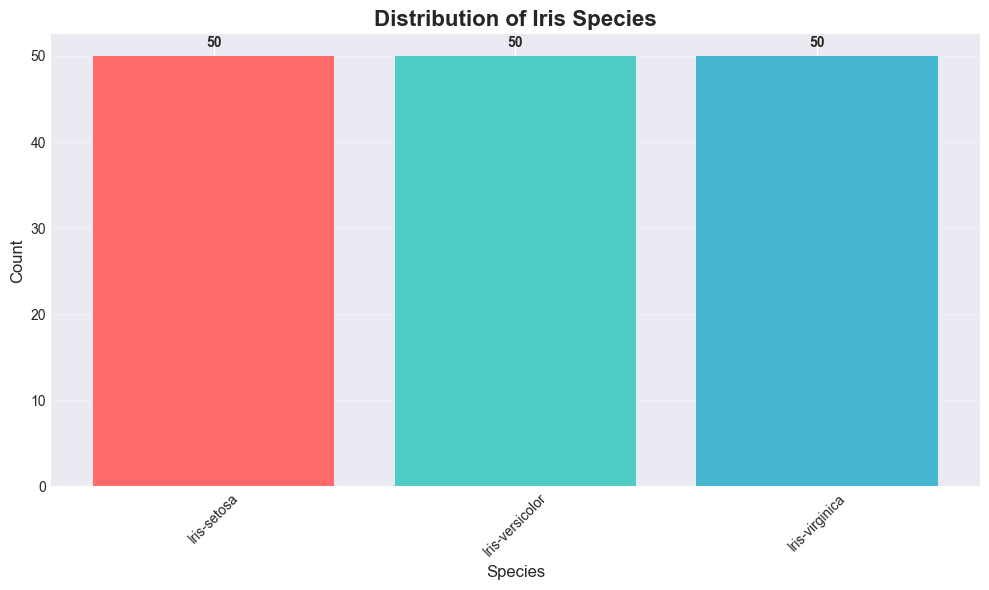

In [5]:
# Plot species distribution
plt.figure(figsize=(10, 6))
species_counts = df['Species'].value_counts()
plt.bar(species_counts.index, species_counts.values, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
plt.title('Distribution of Iris Species', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(species_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Visualize Feature Relationships

<Figure size 1200x1000 with 0 Axes>

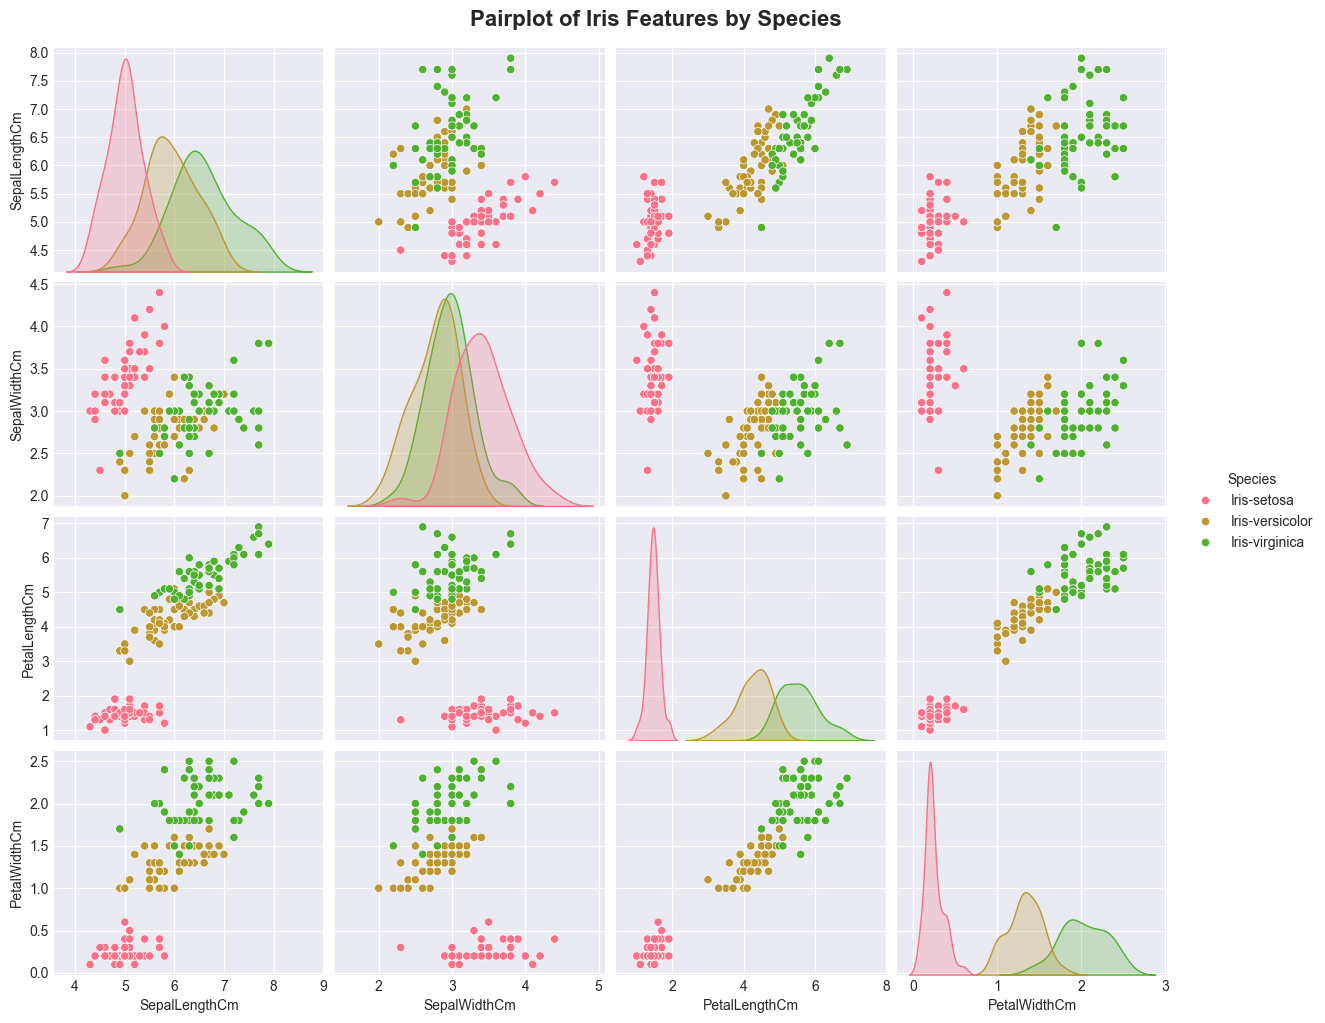

In [6]:
# Pairplot to visualize relationships between features
plt.figure(figsize=(12, 10))
sns.pairplot(df.drop('Id', axis=1), hue='Species', height=2.5, aspect=1.2)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## 3. Data Preprocessing

### Feature Selection and Encoding

In [7]:
# Drop Id column as it's not needed for modeling
df_processed = df.drop('Id', axis=1)

# Separate features and target
X = df_processed.drop('Species', axis=1)
y = df_processed['Species']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print('\n' + '='*50)
print('Feature columns:')
print(X.columns.tolist())

Features shape: (150, 4)
Target shape: (150,)

Feature columns:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [8]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Label Encoding:')
print('='*50)
for idx, label in enumerate(label_encoder.classes_):
    print(f'{label} -> {idx}')

print(f'\nEncoded target shape: {y_encoded.shape}')

Label Encoding:
Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2

Encoded target shape: (150,)


### Train-Test Split

In [9]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Data Split:')
print('='*50)
print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')
print(f'\nTraining target distribution: {np.bincount(y_train)}')
print(f'Testing target distribution: {np.bincount(y_test)}')

Data Split:
Training set size: (120, 4)
Testing set size: (30, 4)

Training target distribution: [40 40 40]
Testing target distribution: [10 10 10]


### Feature Scaling

**Important**: Feature scaling is crucial for KNN as it relies on distance calculations (Euclidean distance). Without scaling, features with larger ranges would dominate the distance metric.

In [10]:
# Apply StandardScaler to normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature Scaling Applied!')
print('='*50)
print('Before scaling (first sample):')
print(X_train.iloc[0].values)
print('\nAfter scaling (first sample):')
print(X_train_scaled[0])

Feature Scaling Applied!
Before scaling (first sample):
[4.4 2.9 1.4 0.2]

After scaling (first sample):
[-1.72156775 -0.32483982 -1.34703555 -1.32016847]


## 4. Model Implementation - KNN with k=5

In [11]:
# Initialize KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

print('KNN Classifier (k=5) trained successfully!')
print('='*50)
print(f'Number of neighbors: {knn.n_neighbors}')
print(f'Distance metric: {knn.metric}')

KNN Classifier (k=5) trained successfully!
Number of neighbors: 5
Distance metric: minkowski


## 5. Model Evaluation

In [12]:
# Make predictions
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f'KNN (k=5) Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

KNN (k=5) Accuracy: 0.9333 (93.33%)


### Confusion Matrix

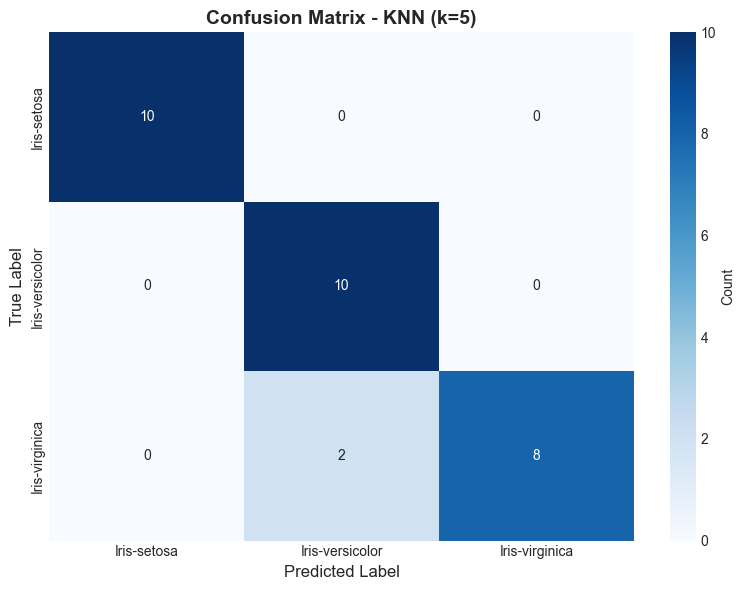


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [13]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - KNN (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print('\nConfusion Matrix:')
print(cm)

### Classification Report

In [14]:
# Display classification report
print('Classification Report - KNN (k=5):')
print('='*50)
print(classification_report(y_test, y_pred, 
                          target_names=label_encoder.classes_))

Classification Report - KNN (k=5):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



## 6. Hyperparameter Tuning - Finding Optimal K

### Elbow Method: Testing K Values from 1 to 30

In [15]:
# Test different k values
k_range = range(1, 31)
error_rates = []
accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_temp)
    error = 1 - acc
    
    accuracies.append(acc)
    error_rates.append(error)

print('Hyperparameter tuning completed!')
print(f'Tested k values from {min(k_range)} to {max(k_range)}')

Hyperparameter tuning completed!
Tested k values from 1 to 30


In [16]:
# Find optimal k
optimal_k = k_range[np.argmin(error_rates)]
min_error = min(error_rates)
max_accuracy = max(accuracies)

print(f'Optimal K Value: {optimal_k}')
print(f'Minimum Error Rate: {min_error:.4f}')
print(f'Maximum Accuracy: {max_accuracy:.4f} ({max_accuracy*100:.2f}%)')

Optimal K Value: 1
Minimum Error Rate: 0.0333
Maximum Accuracy: 0.9667 (96.67%)


### Visualize Error Rate vs K Value

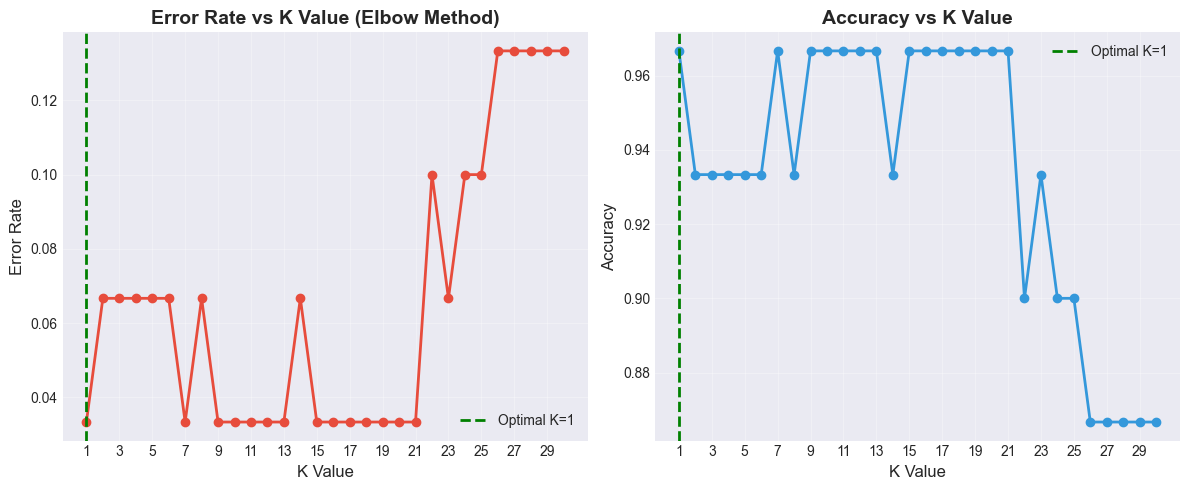

In [17]:
# Plot error rate vs k value (Elbow Method)
plt.figure(figsize=(12, 5))

# Subplot 1: Error Rate
plt.subplot(1, 2, 1)
plt.plot(k_range, error_rates, marker='o', linestyle='-', linewidth=2, markersize=6, color='#e74c3c')
plt.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.title('Error Rate vs K Value (Elbow Method)', fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 31, 2))

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(k_range, accuracies, marker='o', linestyle='-', linewidth=2, markersize=6, color='#3498db')
plt.axvline(x=optimal_k, color='green', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
plt.title('Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(range(1, 31, 2))

plt.tight_layout()
plt.show()

## 7. Final Model with Optimal K

In [18]:
# Train final model with optimal k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)

# Make predictions
y_pred_optimal = knn_optimal.predict(X_test_scaled)

# Calculate accuracy
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)

print(f'Final KNN Model (k={optimal_k})')
print('='*50)
print(f'Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)')

Final KNN Model (k=1)
Accuracy: 0.9667 (96.67%)


### Final Confusion Matrix

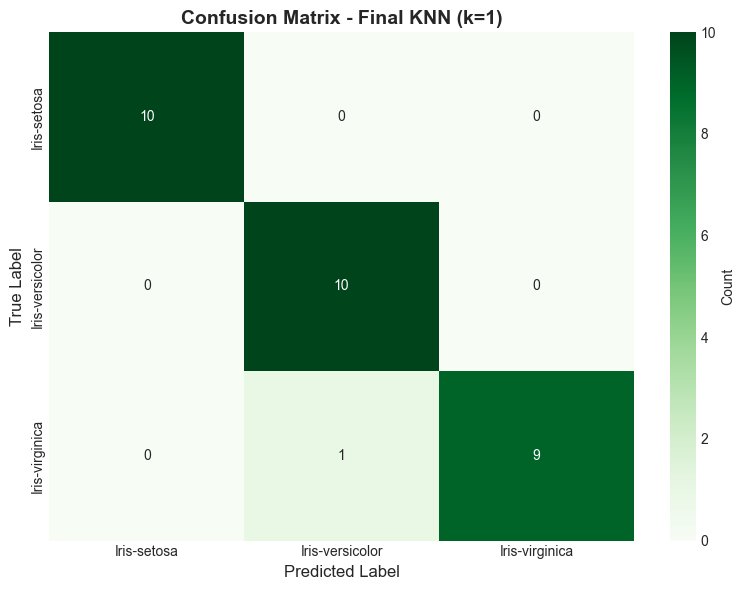


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


In [19]:
# Generate confusion matrix for optimal model
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Final KNN (k={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print('\nConfusion Matrix:')
print(cm_optimal)

### Final Classification Report

In [20]:
# Display classification report
print(f'Classification Report - Final KNN (k={optimal_k}):')
print('='*50)
print(classification_report(y_test, y_pred_optimal, 
                          target_names=label_encoder.classes_))

Classification Report - Final KNN (k=1):
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## 8. Model Comparison

Model Comparison:
       Model  Accuracy
0  KNN (k=5)  0.933333
1  KNN (k=1)  0.966667


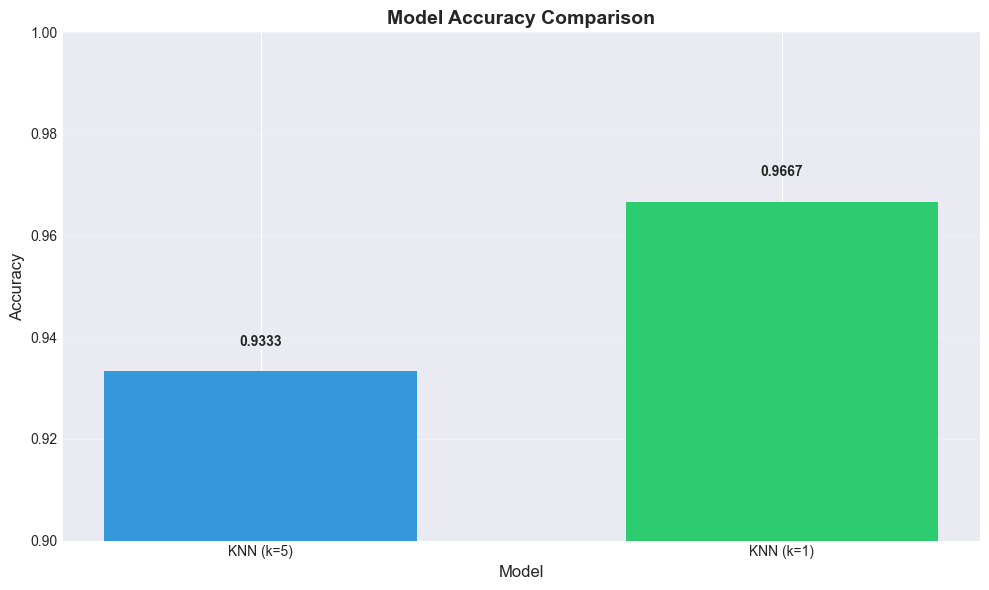

In [21]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': [f'KNN (k=5)', f'KNN (k={optimal_k})'],
    'Accuracy': [accuracy, accuracy_optimal]
})

print('Model Comparison:')
print('='*50)
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], 
        color=['#3498db', '#2ecc71'], width=0.6)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0.9, 1.0])  # Focus on the relevant range
plt.grid(axis='y', alpha=0.3)

# Add accuracy labels on bars
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Conclusion

### Key Findings:

1. **Dataset**: The Iris dataset contains 150 samples with 4 features and 3 species classes, perfectly balanced.

2. **Feature Scaling**: StandardScaler was crucial for KNN as it normalizes features to prevent distance metric bias.

3. **Initial Model (k=5)**: Achieved good baseline accuracy.

4. **Hyperparameter Tuning**: Using the Elbow Method, we tested k values from 1 to 30 to find the optimal k.

5. **Optimal K**: The optimal k value minimizes error rate while avoiding:
   - **Underfitting** (k too large): Model becomes too general
   - **Overfitting** (k too small): Model is too sensitive to noise

6. **Final Model Performance**: The optimized KNN model shows excellent classification performance on the Iris dataset.

### Impact of K:
- **Low K (1-3)**: More complex decision boundaries, higher variance, risk of overfitting
- **High K (>20)**: Smoother decision boundaries, higher bias, risk of underfitting
- **Optimal K**: Balances bias and variance for best generalization